In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

In [5]:
import pandas as pd
df=pd.DataFrame(X)
df['class']=y
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## Data Exploration

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
df.describe().T

,count,unique,top,freq
buying,1728,4,vhigh,432
maint,1728,4,vhigh,432
doors,1728,4,2,432
persons,1728,3,2,576
lug_boot,1728,3,small,576
safety,1728,3,low,576
class,1728,4,unacc,1210


In [8]:
col=df.columns

## Data Visualization

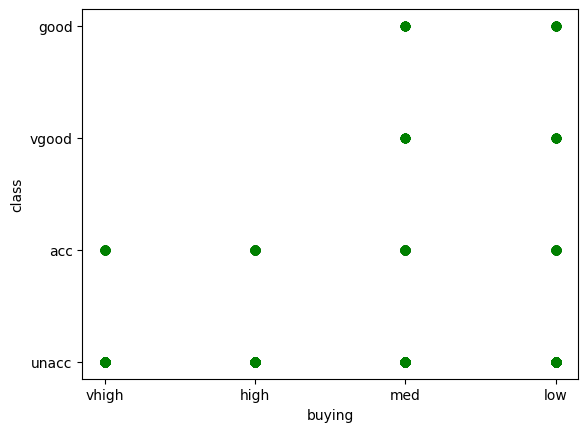

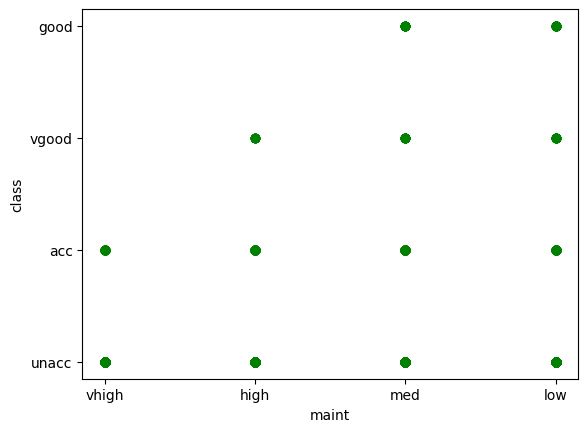

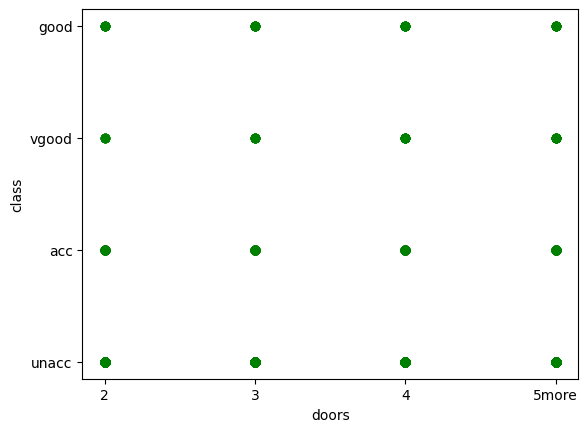

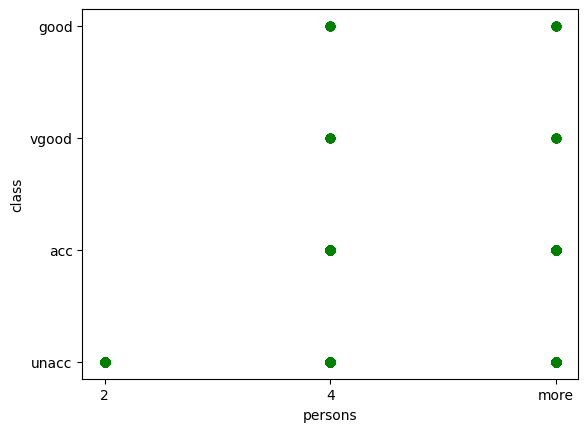

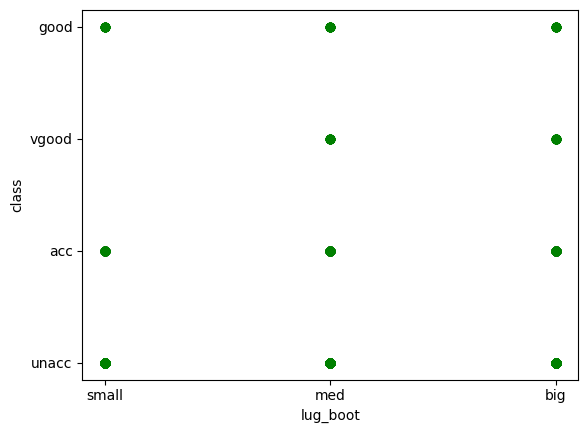

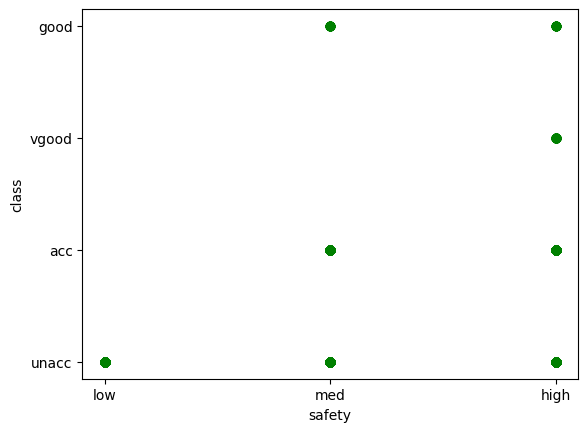

In [13]:
import matplotlib.pyplot as plt

for i in col[:len(col)-1]:
  plt.figure()
  plt.scatter(df[i],df['class'],alpha=0.6,color='g')
  plt.xlabel(i)
  plt.ylabel('class')
  plt.show()

## Data Preparation

In [16]:
col.drop(['doors','persons'])

Index(['buying', 'maint', 'lug_boot', 'safety', 'class'], dtype='object')

In [17]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in col:
  df[i]=le.fit_transform(df[i])

In [18]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


## Model Training

### Without Hyperparameter

In [19]:
X=df.drop('class',axis=1)
y=df['class']

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [24]:
y_pred_1=rf.predict(x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_1))


              precision    recall  f1-score   support

           0       0.99      0.90      0.94        83
           1       0.65      1.00      0.79        11
           2       0.99      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.98       346



### With Hyperparameter

In [25]:
param_grid={
    'n_estimators':[50,100,150,200],
    'criterion':['gini','entropy'],
    'max_depth':[None,5,10,15],
    'max_features':['sqrt','log2'],
    'random_state':[None,42],
    'class_weight':[None,'balanced']
}

In [29]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
gs=GridSearchCV(rf,param_grid)
gs.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 150, 200],
                         'random_state': [None, 42]})

In [28]:
rs=RandomizedSearchCV(rf,param_grid)
rs.fit(x_train,y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 5, 10, 15],
                                        'max_features': ['sqrt', 'log2'],
                                        'n_estimators': [50, 100, 150, 200],
                                        'random_state': [None, 42]})

In [30]:
y_pred_2=gs.predict(x_test)
y_pred_3=rs.predict(x_test)

In [33]:
print("Without Hyperparameter")
print(classification_report(y_test,y_pred_1))
print("GridSearch")
print(classification_report(y_test,y_pred_2))
print("RandomSearch")
print(classification_report(y_test,y_pred_3))

Without Hyperparameter
              precision    recall  f1-score   support

           0       0.99      0.90      0.94        83
           1       0.65      1.00      0.79        11
           2       0.99      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.98       346

GridSearch
              precision    recall  f1-score   support

           0       0.99      0.88      0.93        83
           1       0.55      1.00      0.71        11
           2       1.00      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.88      0.96      0.90       346
weighted avg       0.98      0.97      0.97       346

RandomSearch
              precision    recall  f1-score   support

           0       0.97     

In [34]:
print(f"Best hyperparameters found by GridSearchCV: {gs.best_params_}")
print(f"Best hyperparameters found by RandomizedSearchCV: {rs.best_params_}")

Best hyperparameters found by GridSearchCV: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 150, 'random_state': None}
Best hyperparameters found by RandomizedSearchCV: {'random_state': 42, 'n_estimators': 150, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'entropy', 'class_weight': 'balanced'}
